> 📓 **Lesson 1.10 — Part 1 of 4: The Three Pillars**
>
> This notebook was split out of the original single `data_visualization_lesson.ipynb` so each part can be opened and run on its own. If you are starting here rather than at Part 1, run the **Setup** cell below first — it loads the same data used throughout Lesson 1.10.
>
> Other notebooks in this set: `Part_2_matplotlib_fundamentals.ipynb`, `Part_3_seaborn.ipynb`, `Part_4_chart_choice.ipynb`

# Lesson 1.10: Data Visualisation & Storytelling

Lesson 1.8 asked *can I trust this data?* Lesson 1.9 asked *what is the pattern?* You answered both.
You have a table that shows exactly what is happening to the café chain.

This lesson is about the last twenty seconds — the part where the owner either acts on it or doesn't.

**Structure — the four learning outcomes, in order:**
* **Part 1: The Three Pillars** — *apply* perception, design and storytelling to fix a bad chart.
* **Part 2: Matplotlib Fundamentals** — *create* charts with the Figure → Axes → plot hierarchy.
* **Part 3: Seaborn for Statistical Graphics** — *use* the right statistical view for the data type.
* **Part 4: Chart Choice & the One Slide** — *select* the chart your message needs, and build it.

**How to work through this:** read the `# 👉` comment above each line before you run the cell. Charts are the one
topic where you learn most by breaking things on purpose, so several cells here are deliberately bad.


> **🧭 Today's flow — 180 minutes.** One message, four learning outcomes, in order:
>
> | | Section | Learning outcome | Time |
> |---|---|---|---|
> | — | Setup + why this matters | | 5 min |
> | **Part 1** | The Three Pillars | **Apply** perception, design, storytelling | 40 min |
> | ☕ | *Break* | | 10 min |
> | **Part 2** | Matplotlib Fundamentals | **Create** charts: Figure → Axes → plot | 45 min |
> | ☕ | *Break* | | 10 min |
> | **Part 3** | Seaborn | **Use** statistical graphics for the data type | 45 min |
> | **Part 4** | Chart Choice & the One Slide | **Select** the chart the message needs | 25 min |
>
> **The spine:** the same business problem as 1.9 — *The Daily Grind* café chain — and the same
> files. You already know the answer. Today you make it land.
>
> Each of Parts 1–3 ends with a **🛠️ Group Exercise**. Deep dives (colour theory, accessibility,
> Gestalt, the research behind pre-attentive processing) live in `reference.md`.


### The one rule this lesson is built on

> **The chart is chosen by the message, not by taste.**

Write the sentence you want the audience to leave with, in words, first. The chart type follows from
that sentence almost mechanically. Every mistake in Part 1 comes from doing it the other way round —
picking a chart, then hunting for something to say.


### Setup


In [14]:
# 👉 pandas for the data, matplotlib for drawing, seaborn for statistical charts.
#    `plt` and `sns` are the conventional nicknames -- you will see them in every tutorial.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 👉 Housekeeping only: keep version-deprecation notices out of our output.
import warnings
warnings.filterwarnings("ignore")

# 👉 Draw charts underneath the cell that made them, inside the notebook.
%matplotlib inline


In [15]:
# 👉 The same café data as Lesson 1.9, plus the decision table you produced at the end of it.
sales = pd.read_csv("../data/daily_sales.csv", parse_dates=["date"])
outlets = pd.read_csv("../data/outlets.csv", parse_dates=["opened_date"])
tickets = pd.read_csv("../data/tickets_week.csv", parse_dates=["txn_datetime"])
decision = pd.read_csv("../data/lesson19_decision.csv", index_col="outlet_id")

decision.round(1)


,outlet_name,rev_2025_h1,change_pct,rent_pct_of_revenue,rev_per_staff_hour
outlet_id,,,,,
OUT-03,Marina Bay,203147.5,-27.9,28.4,19.9
OUT-01,Raffles Place,309339.2,-1.5,15.9,26.4
OUT-02,Tampines Mall,279272.0,1.3,14.6,25.5
OUT-04,Holland Village,253450.1,26.5,14.7,26.7
OUT-05,NaN,61309.5,NaN,NaN,26.0


In [16]:
# 👉 Two summaries we will chart all session. Both are straight out of Lesson 1.9.
#    (1) monthly revenue per outlet -- one column per outlet, dates on the index.
monthly = sales.pivot_table(
    index="date", columns="outlet_id", values="revenue_sgd", aggfunc="sum"
).resample("M").sum()

# 👉 (2) revenue by outlet and daypart.
by_daypart = sales.pivot_table(
    index="outlet_id", columns="daypart", values="revenue_sgd", aggfunc="sum"
)[["Morning", "Midday", "Evening"]]

# 👉 Friendly names, for chart labels. Codes belong in databases, not on slides.
names = outlets.set_index("outlet_id")["outlet_name"].to_dict()

monthly.tail(5).round(0)

# by_daypart.round(0)


outlet_id,OUT-01,OUT-02,OUT-03,OUT-04,OUT-05
date,,,,,
2025-02-28,47764.0,42186.0,32165.0,38456.0,0.0
2025-03-31,50549.0,48397.0,34927.0,45970.0,20493.0
2025-04-30,53250.0,47146.0,33777.0,41892.0,19595.0
2025-05-31,52570.0,50158.0,33822.0,44123.0,21221.0
2025-06-30,53255.0,44896.0,32818.0,44700.0,0.0


### 🎬 Why this matters — the same finding, three ways

**The situation.** You have five minutes at the end of a Monday meeting. The owner is deciding
whether to renew the Marina Bay lease. You already know the answer: chain revenue is flat because
Marina Bay is falling and Holland Village is rising, and Marina Bay's fall is a step dated to the
first week of November 2024.

Below is that finding presented three ways. Same data. Same truth. Run all three, then decide which
one makes somebody *do* something.


In [17]:
# 👉 Version 1: the numbers. Complete, precise, and almost impossible to read at speed.
monthly.round(0).tail(12)


outlet_id,OUT-01,OUT-02,OUT-03,OUT-04,OUT-05
date,,,,,
2024-07-31,55315.0,48409.0,48581.0,36779.0,0.0
2024-08-31,52530.0,48299.0,47079.0,38089.0,0.0
2024-09-30,50083.0,45214.0,43679.0,36634.0,0.0
2024-10-31,54212.0,44320.0,46138.0,37368.0,0.0
2024-11-30,48362.0,45761.0,35344.0,37488.0,0.0
2024-12-31,51839.0,46734.0,33956.0,39548.0,0.0
2025-01-31,51951.0,46489.0,35638.0,38309.0,0.0
2025-02-28,47764.0,42186.0,32165.0,38456.0,0.0
2025-03-31,50549.0,48397.0,34927.0,45970.0,20493.0


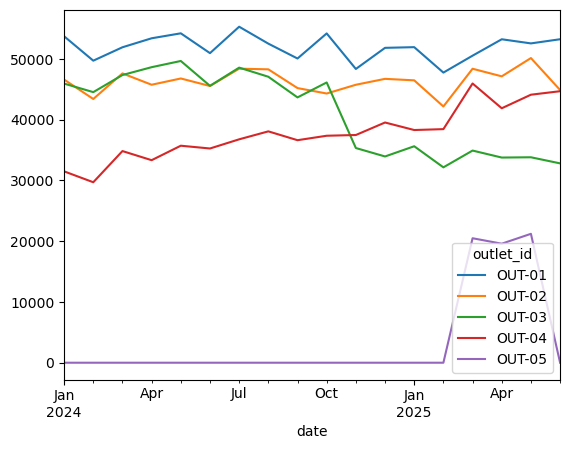

In [18]:
# 👉 Version 2: a chart, made without thinking. Every default left as it came.
monthly.plot()
plt.show()


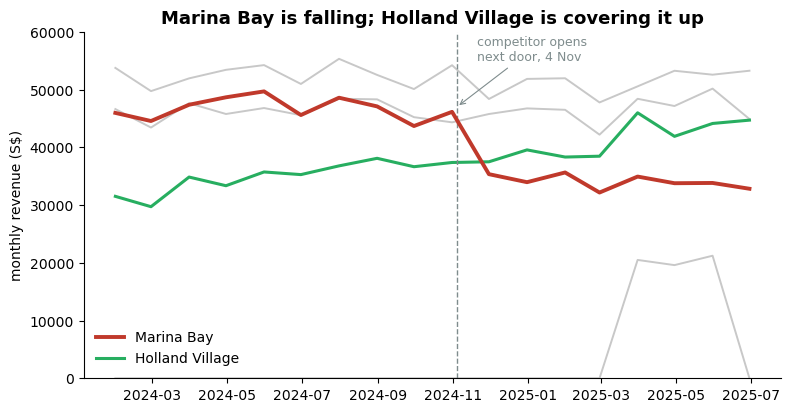

In [19]:
# 👉 Version 3: the same numbers, drawn to make one point. Read the code later --
#    for now just compare what your eye does with this versus the two above.
# color codes: https://htmlcolorcodes.com/color-names/

fig, ax = plt.subplots(figsize=(9, 4.5))

for col in monthly.columns:
    if col == "OUT-03":
        ax.plot(monthly.index, monthly[col], color="#c0392b", linewidth=2.8, label="Marina Bay", zorder=3) # zorder controls which lines are drawn on top of which others, 3 is the highest here
    elif col == "OUT-04":
        ax.plot(monthly.index, monthly[col], color="#27ae60", linewidth=2.2, label="Holland Village", zorder=2)
    else:
        ax.plot(monthly.index, monthly[col], color="#c8c8c8", linewidth=1.4, zorder=1)

ax.axvline(pd.Timestamp("2024-11-04"), color="#7f8c8d", linestyle="--", linewidth=1)
ax.annotate("competitor opens\nnext door, 4 Nov",
            xy=(pd.Timestamp("2024-11-04"), 47000), xytext=(pd.Timestamp("2024-11-20"), 55000),
            fontsize=9, color="#7f8c8d",
            arrowprops=dict(arrowstyle="->", color="#7f8c8d", linewidth=0.8))

ax.set_title("Marina Bay is falling; Holland Village is covering it up", fontsize=13, weight="bold")
ax.set_ylabel("monthly revenue (S$)")
ax.set_ylim(0, 60000)
ax.legend(frameon=False, loc="lower left") # remove the box around the legend
ax.spines[["top", "right"]].set_visible(False) # remove the top and right borders
plt.show()


**What changed between versions 2 and 3?** Nothing about the data. Four things about the drawing:

1. **One sentence as the title.** Not "Monthly Revenue" — the actual finding, in words.
2. **Colour used as an argument.** Two lines carry the point; the other three went grey. Your eye
   found the red line before you consciously read anything. That reflex is *pre-attentive processing*,
   and it fires in 200 to 500 milliseconds. Charts either use it or waste it.
3. **The cause annotated on the chart.** The reader does not have to be told separately.
4. **Clutter removed.** Two spines gone, no box round the legend, no chart junk competing for attention.

That is the whole lesson: **perception** (how eyes work), **design** (honest, uncluttered choices),
**storytelling** (one message, stated). Everything else is syntax.


---

## Part 1: The Three Pillars

**Learning outcome 1:** *Apply the three storytelling pillars (Perception, Design, Storytelling) to
evaluate and improve visualisations.*

**Goal:** take a genuinely bad chart and fix it in five moves, saying which pillar each move serves.

⏱️ ~40 min including Group Exercise 1


### 1.1: Pillar 1 — Perception: what the eye does before you think

Two facts about human vision do most of the work in chart design:

| Fact | What it means for you |
|---|---|
| **Pre-attentive processing** — colour, length and position register in ~200ms, before conscious attention | one contrasting element is found instantly; ten are found never |
| **Working memory holds about four things** | every extra colour, line or label spends a limited budget |

Length along a common baseline is the most accurately judged visual channel; angle and area are among
the worst. That single ranking is why bar charts beat pie charts, and why nothing good ever came of a
3D exploding donut.


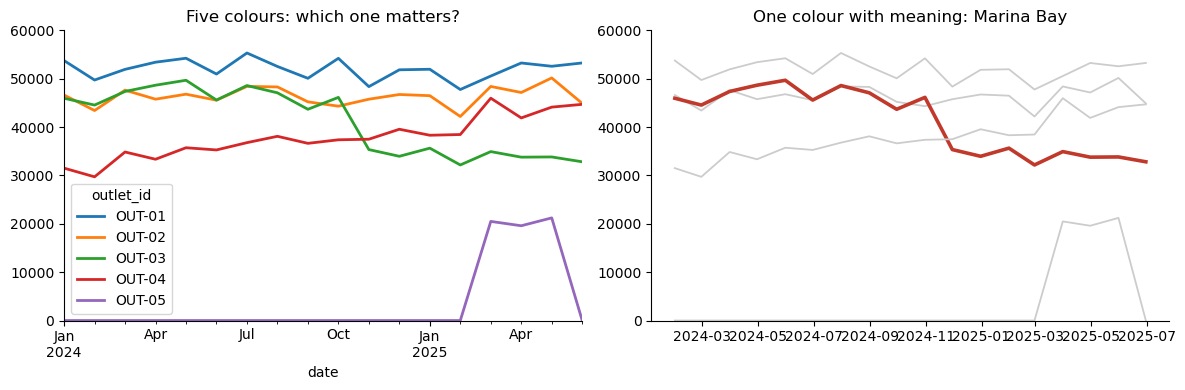

In [20]:
# 👉 Proof, on data you know. Left: five colours, everything shouting. Right: one red, four greys.
#    Ask yourself how long each takes to answer "which outlet is falling?"
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) # 1 row, 2 columns of charts

# Left: five colours, everything shouting
monthly.plot(ax=axes[0], linewidth=2)
axes[0].set_title("Five colours: which one matters?") 

# Right: one red, four greys
for col in monthly.columns:
    highlight = col == "OUT-03"
    axes[1].plot(monthly.index, monthly[col],
                 color="#c0392b" if highlight else "#cccccc",
                 linewidth=2.6 if highlight else 1.3)
axes[1].set_title("One colour with meaning: Marina Bay")

for ax in axes:
    ax.set_ylim(0, 60000)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout() # adjust the spacing between the two charts so titles don't overlap
plt.show() # display the charts


> **The grey is not decoration.** The four grey lines still supply the context that makes the red one
> meaningful — without them you cannot see that the others are steady. Grey is how you keep context
> without spending attention on it.


### 1.2: Pillar 2 — Design: the same numbers, honest and not

Design is mostly about *not lying*. The most common lie in business reporting is the truncated axis.

Further reading: https://medium.com/@Ana_kin/graphs-gone-wrong-misleading-data-visualizations-d4805d1c4700


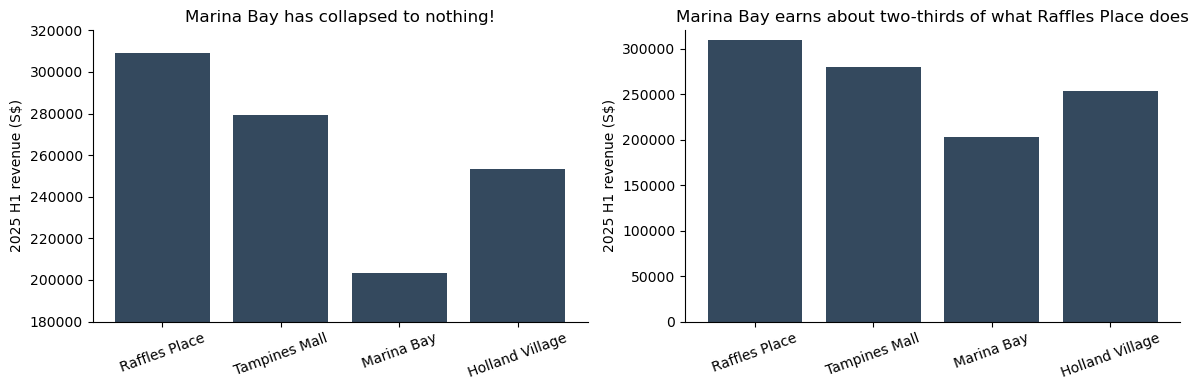

In [21]:
# 👉 Both panels plot the same four numbers: 2025 H1 revenue per outlet.
#    The only difference is where the y-axis starts.
h1 = decision.loc[["OUT-01", "OUT-02", "OUT-03", "OUT-04"], "rev_2025_h1"]
labels = [names[i] for i in h1.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels, h1, color="#34495e")
axes[0].set_ylim(180000, 320000)          # 👈 the lie: axis starts at 180,000
axes[0].set_title("Marina Bay has collapsed to nothing!")

axes[1].bar(labels, h1, color="#34495e")
axes[1].set_ylim(0, 320000)               # 👈 the truth: bars start at zero
axes[1].set_title("Marina Bay earns about two-thirds of what Raffles Place does")

for ax in axes:
    ax.set_ylabel("2025 H1 revenue (S$)")
    ax.tick_params(axis="x", labelrotation=20)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


> **Why this one rule matters more than the others.** A bar chart encodes value as **length**. If the
> axis does not start at zero, the length is no longer proportional to the value, and the reader's
> eye is doing arithmetic on a false premise. In the left panel Marina Bay looks like it earns
> perhaps a tenth of what Raffles Place earns. It earns 66% of it.
>
> **Line charts are different.** They encode *position* and are read for *change*, so a truncated
> axis is often the right choice — it lets you see a 3% move that would be invisible on a
> zero-based axis. Rule: **bars start at zero; lines start wherever the change is legible.**


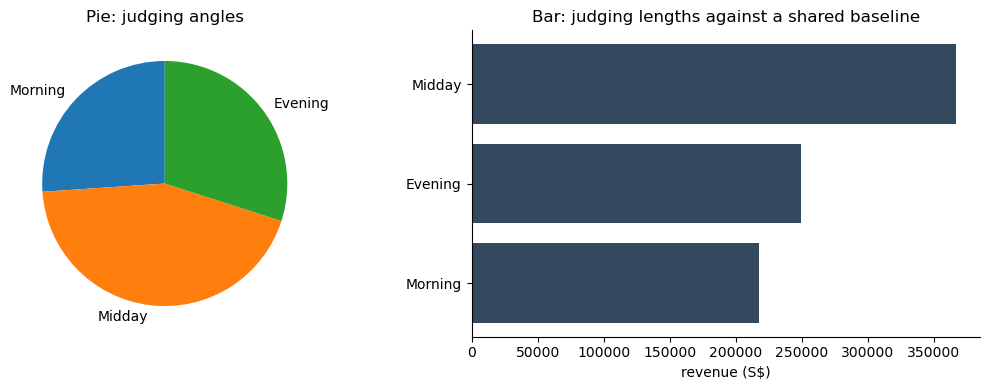

In [22]:
# 👉 Second design trap: the pie chart. Same data, twice. Which is the second-biggest daypart
#    for Tampines Mall? Time yourself on the left, then on the right.
tampines = by_daypart.loc["OUT-02"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].pie(tampines, labels=tampines.index, startangle=90)
axes[0].set_title("Pie: judging angles")

tampines_sorted = tampines.sort_values()  # ascending so barh puts largest on top
axes[1].barh(tampines_sorted.index, tampines_sorted.values, color="#34495e")
axes[1].set_title("Bar: judging lengths against a shared baseline")
axes[1].set_xlabel("revenue (S$)")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


> Pie charts are not banned — for "roughly half versus roughly a quarter", with two or three slices,
> they are fine and familiar. They fail when the shares are close, or when there are more than about
> four of them, because comparing angles is something human vision is measurably bad at.


### 1.3: Pillar 3 — Storytelling: fix a bad chart in five moves

Here is a chart that is not *wrong*. It is just useless. Run it, then we fix it one move at a time,
naming the pillar each move serves.


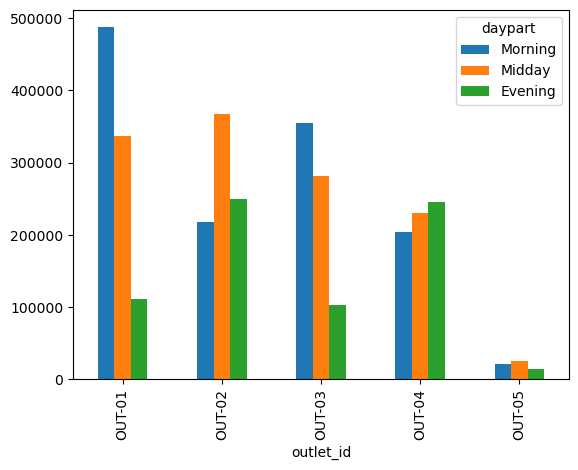

In [23]:
# 👉 The "before". Every default accepted, no thought applied.
by_daypart.plot(kind="bar")
plt.show()


**What is wrong with it?** List everything you can find before reading on.

- The x labels are outlet *codes*, so the reader has to translate.
- Nothing says what the chart is for. "What am I looking at?" has no answer.
- Absolute dollars, so the two biggest outlets dominate and the *pattern* is invisible.
- The legend order (Morning, Midday, Evening) is accidental, not chosen.
- No axis units. Are those dollars? Thousands? Tickets?


In [24]:
# 👉 Move 1 (design): change the numbers to answer the actual question.
#    We care about the MIX, not the size, so convert each row to percentages of itself.
mix = (by_daypart.div(by_daypart.sum(axis=1), axis=0) * 100).round(1)

mix


daypart,Morning,Midday,Evening
outlet_id,,,
OUT-01,52.1,36.0,11.9
OUT-02,26.1,44.0,29.9
OUT-03,48.0,38.0,13.9
OUT-04,30.0,34.0,36.1
OUT-05,33.9,42.4,23.7


In [25]:
# 👉 Move 2 (perception): drop the pop-up kiosk -- it closed, and it is not part of the question.
#    Move 3 (design): real names instead of codes.
mix4 = mix.drop(index="OUT-05")
mix4.index = [names[i] for i in mix4.index]

mix4


daypart,Morning,Midday,Evening
Raffles Place,52.1,36.0,11.9
Tampines Mall,26.1,44.0,29.9
Marina Bay,48.0,38.0,13.9
Holland Village,30.0,34.0,36.1


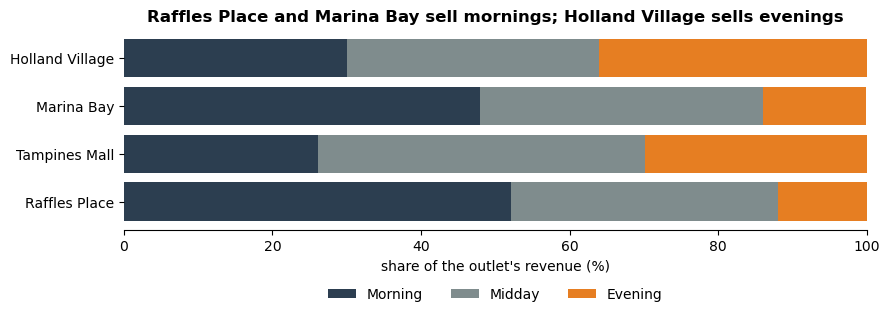

In [26]:
# 👉 Moves 4 and 5, both storytelling: a title that states the finding, and a horizontal
#    stacked bar so the three shares of each outlet read as one 100% row.
fig, ax = plt.subplots(figsize=(9, 3.6))

left = np.zeros(len(mix4))
colours = {"Morning": "#2c3e50", "Midday": "#7f8c8d", "Evening": "#e67e22"}

for part in ["Morning", "Midday", "Evening"]:
    ax.barh(mix4.index, mix4[part], left=left, color=colours[part], label=part)
    left += mix4[part].values

ax.set_title("Raffles Place and Marina Bay sell mornings; Holland Village sells evenings",
             fontsize=12, weight="bold")
ax.set_xlabel("share of the outlet's revenue (%)")
ax.set_xlim(0, 100)
ax.legend(frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.42))
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
plt.show()


**The five moves, and the pillar each one served:**

| Move | Pillar | Why |
|---|---|---|
| 1. Percentages, not dollars | Design | matches the number to the question (mix, not size) |
| 2. Removed the kiosk | Perception | one fewer thing competing for a four-item memory budget |
| 3. Real names | Perception | no mental translation step |
| 4. Title states the finding | Storytelling | the reader gets the message even if they read nothing else |
| 5. Stacked horizontal bars | Design | each row is one 100% whole; long labels fit horizontally |

**Nothing about the data changed.** The chart went from useless to actionable purely through
presentation choices — and every choice traces back to one of the three pillars.


### 🛠️ Group Exercise 1 — Critique and fix (8 min)

Fill in the blanks to build a bar chart of `rent_pct_of_revenue`, with Marina Bay in red and the rest grey:
```python
r = decision["rent_pct_of_revenue"].dropna().sort_values()
colours = ["#c0392b" if i == "______" else "#cccccc" for i in r.index]
fig, ax = plt.subplots()
ax.barh([names[i] for i in r.index], r.values, color=______)
ax.set_ylim(____)   # careful -- is a y-limit even the right thing for a horizontal bar chart?
```
*Expected:* Marina Bay's bar is roughly twice everyone else's. Note that for `barh` it is the **x**-axis that carries the value, so `set_xlim(0, ...)` is the zero-baseline rule here.

---

## ✅ Sample Solution

Try the exercise yourself first — this is *a* solution, not *the* solution. If your code reaches the same answer a different way, it is right.

**The blanks filled in.**

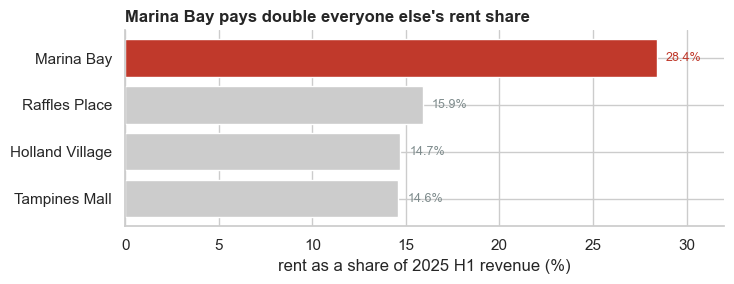

In [47]:
# 👉 The blanks filled in. Three of them:
#      "______"  -> "OUT-03"     (Marina Bay's code -- the highlight)
#      color=____ -> colours      (the list built on the line above)
#      set_ylim   -> WRONG METHOD. For barh, the value runs along x, so it is set_xlim(0, ...).
r = decision["rent_pct_of_revenue"].dropna().sort_values()
colours = ["#c0392b" if i == "OUT-03" else "#cccccc" for i in r.index]

fig, ax = plt.subplots(figsize=(7.5, 3))
ax.barh([names[i] for i in r.index], r.values, color=colours)

ax.set_xlim(0, 32)                    # 👈 the zero-baseline rule, on the axis that carries the value

# 👉 Direct labels beat a gridline the reader has to trace back to an axis.
for y, v in enumerate(r.values):
    ax.text(v + 0.5, y, f"{v:.1f}%", va="center", fontsize=9,
            color="#c0392b" if r.index[y] == "OUT-03" else "#7f8c8d")

ax.set_xlabel("rent as a share of 2025 H1 revenue (%)")
ax.set_title("Marina Bay pays double everyone else's rent share", loc="left", weight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# 👉 Expected, and confirmed: Tampines 14.6%, Holland Village 14.7%, Raffles Place 15.9%,
#    Marina Bay 28.4% -- about 1.8x the others, which is what "roughly twice" meant.

---

# ☕ Break — 10 minutes

**Where we are:** you can look at a chart and say what is wrong with it, and why, in the language of
the three pillars.

**Next up:** Part 2 — how matplotlib actually works, so you can build any of it yourself instead of
accepting `.plot()`'s defaults.


📂 **Open** `Part_2_matplotlib_fundamentals.ipynb` to continue.